In [25]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer
import joblib

In [26]:
df_frequency = pd.read_csv("data/frequency2.csv")

In [27]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1,"(21.0, 25.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1,"(17.999, 21.0]",0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1,"(41.0, 45.0]",1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1,"(17.999, 21.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1,"(29.0, 33.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²


In [28]:
df_severity = pd.read_csv("data/severity2.csv")

In [29]:
df_severity.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD,age_bucket,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740,"(36.0, 41.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",2.0,193 - 297 inh/km²
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207,"(23.0, 25.0]",0.0,18 - 35,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803,"(28.0, 32.0]",0.0,18 - 35,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868,"(46.0, 54.0]",1.0,35 - 53,1.0,"€15,076 - €31,188",1.0,97 - 193 inh/km²
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746,"(46.0, 54.0]",1.0,35 - 53,0.0,"€1,000 - €15,076",2.0,193 - 297 inh/km²


## Frequency Model

In [ ]:
formula_freq = "claimNumbMD ~ gender + carType + carCat + job + nYears + age * density + carVal + cover"

In [31]:
model_freq = smf.glm(
    formula=formula_freq, data=df_frequency, family=sm.families.Poisson()
).fit()

In [32]:
print(model_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24735
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20162.
Date:                Tue, 05 May 2026   Deviance:                       15813.
Time:                        17:18:40   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05565
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.3501 

so `carCat` doesn't seem to be significant at all. I'm gonna drop it

In [33]:
formula_freq_v2 = (
    "claimNumbMD ~ gender + carType + job + nYears + age * density + carVal + cover"
)

In [34]:
model_freq_v2 = smf.glm(
    formula=formula_freq_v2, data=df_frequency, family=sm.families.Poisson()
).fit()

In [35]:
print(model_freq_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimNumbMD   No. Observations:                24753
Model:                            GLM   Df Residuals:                    24737
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20163.
Date:                Tue, 05 May 2026   Deviance:                       15814.
Time:                        17:18:41   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05560
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.3546 

the is no significant difference between the car types **A** and **B**. Also, `carVal` practically has no effect on severity

## Severity Model

In [ ]:
formula_sev = "claimSizeMD ~ gender + carType + carCat + job + nYears + age * density + carVal + cover"

In [37]:
model_sev = smf.glm(
    formula=formula_sev,
    data=df_severity,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [38]:
print(model_sev.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12256
Model:                            GLM   Df Residuals:                    12238
Model Family:                   Gamma   Df Model:                           17
Link Function:                    Log   Scale:                          1.0500
Method:                          IRLS   Log-Likelihood:                    inf
Date:                Tue, 05 May 2026   Deviance:                       14535.
Time:                        17:18:41   Pearson chi2:                 1.29e+04
No. Iterations:                    17   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.9011 

/home/arad/ku-leuven/Statistical-Consulting-Project/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:812: RuntimeWarning: divide by zero encountered in log
  ll_obs -= special.gammaln(weight_scale) + np.log(endog)
/home/arad/ku-leuven/Statistical-Consulting-Project/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: invalid value encountered in scalar subtract
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


In [39]:
(df_severity["claimSizeMD"] == 0).any()

np.True_

there are some zero values for the target in the severity data. we should handle that.
Also dropping the carCat covariate.

In [40]:
df_severity_clean = df_severity[df_severity["claimSizeMD"] > 0].copy()

In [41]:
formula_sev_v2 = (
    "claimSizeMD ~ gender + carType + job + nYears + age * density + carVal + cover"
)

In [42]:
model_sev_v2 = smf.glm(
    formula=formula_sev_v2,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [43]:
print(model_sev_v2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12236
Model Family:                   Gamma   Df Model:                           15
Link Function:                    Log   Scale:                          1.0490
Method:                          IRLS   Log-Likelihood:                -94578.
Date:                Tue, 05 May 2026   Deviance:                       14256.
Time:                        17:18:42   Pearson chi2:                 1.28e+04
No. Iterations:                    16   Pseudo R-squ. (CS):            0.08319
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.8874 

`carVal`, and the age and density interaction don't seem to be important in the severity of the claim. dropping these covariates and refitting the model

In [44]:
formula_sev_v3 = "claimSizeMD ~ gender + carType + job + nYears + age + density + cover"

In [45]:
model_sev_v3 = smf.glm(
    formula=formula_sev_v3,
    data=df_severity_clean,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

In [46]:
print(model_sev_v3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claimSizeMD   No. Observations:                12252
Model:                            GLM   Df Residuals:                    12238
Model Family:                   Gamma   Df Model:                           13
Link Function:                    Log   Scale:                          1.0492
Method:                          IRLS   Log-Likelihood:                -94580.
Date:                Tue, 05 May 2026   Deviance:                       14260.
Time:                        17:18:42   Pearson chi2:                 1.28e+04
No. Iterations:                    15   Pseudo R-squ. (CS):            0.08286
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.9720 

## Combining the results

In [47]:
df_frequency["Expected_Frequency"] = model_freq_v2.predict(df_frequency)

In [48]:
df_frequency["Expected_Severity"] = model_sev_v3.predict(df_frequency)

In [49]:
df_frequency["Expected_Cost"] = (
    df_frequency["Expected_Frequency"] * df_frequency["Expected_Severity"]
)

In [50]:
df_frequency[["Expected_Frequency", "Expected_Severity", "Expected_Cost"]]

,Expected_Frequency,Expected_Severity,Expected_Cost
0,0.583289,880.553734,513.616957
1,0.664594,687.287756,456.767578
2,0.636383,850.730536,541.390531
3,0.596154,624.533044,372.317849
4,0.456059,659.725346,300.873411
...,...,...,...
24748,0.674204,999.123345,673.613392
24749,0.568238,810.811198,460.733919
24750,0.128279,702.867922,90.163320
24751,0.621226,847.209782,526.309014


In [51]:
cols_to_show = [
    "gender",
    "age",
    "carType",
    "job",
    "density",
    "Expected_Cost",
]

In [52]:
summary_df = df_frequency[cols_to_show].copy()

In [53]:
summary_df["Expected_Cost"] = summary_df["Expected_Cost"].apply(
    lambda x: f"€{x:,.2f}" if isinstance(x, (int, float)) else x
)

In [54]:
summary_df

,gender,age,carType,job,density,Expected_Cost
0,Male,25,C,Employed,72.012883,€513.62
1,Male,20,E,Employed,39.550411,€456.77
2,Female,42,E,Unemployed,169.529148,€541.39
3,Female,21,C,Housewife,58.894688,€372.32
4,Female,33,D,Employed,109.631885,€300.87
...,...,...,...,...,...,...
24748,Male,22,D,Unemployed,23.218206,€673.61
24749,Female,26,E,Unemployed,22.241294,€460.73
24750,Female,74,E,Retired,32.390521,€90.16
24751,Male,24,E,Employed,145.223003,€526.31


## Building the Risk Tier

In [55]:
costs = df_frequency[["Expected_Cost"]].copy()

In [56]:
inertia_values = []
K_range = range(2, 9)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=25)
    kmeans_test.fit(costs)
    inertia_values.append(kmeans_test.inertia_)

    print(f"Tested k = {k}, Inertia: {kmeans_test.inertia_:,.0f}")

Tested k = 2, Inertia: 471,699,499
Tested k = 3, Inertia: 240,339,611
Tested k = 4, Inertia: 146,685,255
Tested k = 5, Inertia: 96,314,727
Tested k = 6, Inertia: 69,395,231
Tested k = 7, Inertia: 51,624,679
Tested k = 8, Inertia: 40,062,090


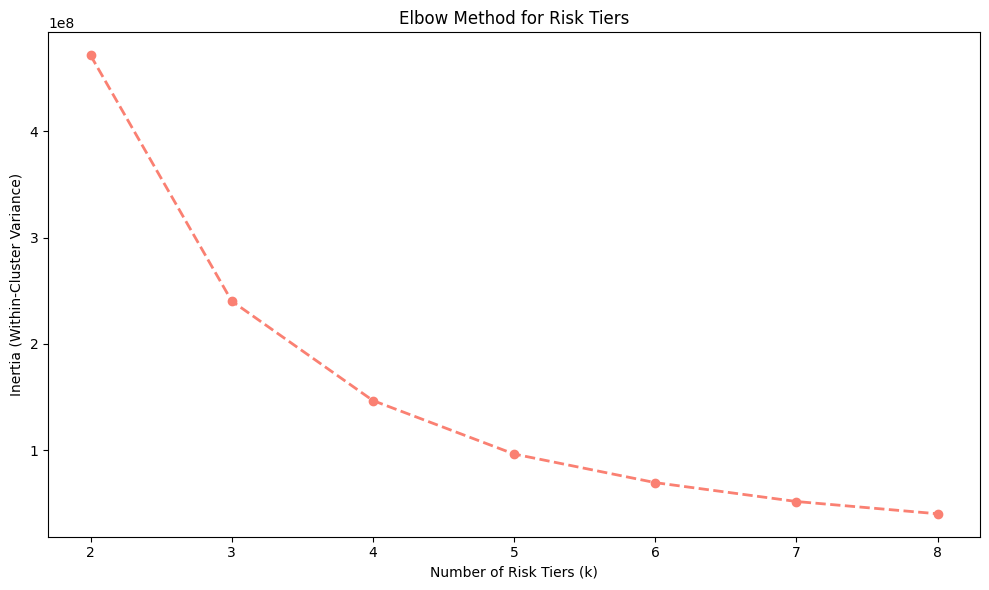

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    K_range, inertia_values, marker="o", linestyle="--", color="salmon", linewidth=2
)
ax.set_title("Elbow Method for Risk Tiers")
ax.set_xlabel("Number of Risk Tiers (k)")
ax.set_ylabel("Inertia (Within-Cluster Variance)")

fig.tight_layout()

In [58]:
OPTIMUM_NUM_K = 4

In [59]:
discretizer = KBinsDiscretizer(
    n_bins=OPTIMUM_NUM_K, encode="ordinal", strategy="kmeans", random_state=36
)

In [60]:
binned_costs = discretizer.fit_transform(costs)

In [61]:
risk_labels = {
    0.0: "Low Risk",
    1.0: "Medium Risk",
    2.0: "High Risk",
    3.0: "Extreme Risk",
}

In [62]:
df_frequency["risk_flag"] = pd.Series(binned_costs.flatten()).map(risk_labels)

In [63]:
edges = discretizer.bin_edges_[0]
print("EXACT EURO BOUNDARIES:\n")
print(f"Low Risk: Up to €{edges[1]:,.2f}")
print(f"Medium Risk: €{edges[1]:,.2f} to €{edges[2]:,.2f}")
print(f"High Risk: €{edges[2]:,.2f} to €{edges[3]:,.2f}")
print(f"Extreme Risk: Above €{edges[3]:,.2f}")

EXACT EURO BOUNDARIES:

Low Risk: Up to €328.37
Medium Risk: €328.37 to €555.45
High Risk: €555.45 to €858.71
Extreme Risk: Above €858.71


In [64]:
risk_summary = (
    df_frequency.groupby("risk_flag")
    .agg(
        customer_count=("risk_flag", "count"),
        minimum_cost=("Expected_Cost", "min"),
        maximum_cost=("Expected_Cost", "max"),
        median_cost=("Expected_Cost", "median"),
    )
    .reset_index()
)

In [65]:
risk_summary = (
    risk_summary.sort_values(by="customer_count", ascending=False)
    .reset_index(drop=True)
    .round(decimals=2)
)
risk_summary

,risk_flag,customer_count,minimum_cost,maximum_cost,median_cost
0,Low Risk,9992,58.20,328.35,230.56
1,Medium Risk,8763,328.38,555.45,424.87
2,High Risk,4627,555.52,858.66,665.96
3,Extreme Risk,1371,858.72,1775.90,986.32


In [66]:
risk_summary.to_csv("data/risk_summary.csv", index=False)

In [67]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,...,age_cluster_code,age_cluster,carVal_cluster_code,carVal_cluster,density_cluster_code,density_cluster,Expected_Frequency,Expected_Severity,Expected_Cost,risk_flag
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,...,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²,0.583289,880.553734,513.616957,Medium Risk
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,...,0.0,18 - 35,1.0,"€15,076 - €31,188",0.0,14 - 97 inh/km²,0.664594,687.287756,456.767578,Medium Risk
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,...,1.0,35 - 53,2.0,"€31,188 - €49,995",1.0,97 - 193 inh/km²,0.636383,850.730536,541.390531,Medium Risk
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,...,0.0,18 - 35,0.0,"€1,000 - €15,076",0.0,14 - 97 inh/km²,0.596154,624.533044,372.317849,Medium Risk
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,...,0.0,18 - 35,0.0,"€1,000 - €15,076",1.0,97 - 193 inh/km²,0.456059,659.725346,300.873411,Low Risk


In [68]:
continuous_cols = [
    "age",
    "nYears",
    "carVal",
    "density",
    "Expected_Frequency",
    "Expected_Severity",
    "Expected_Cost",
]
categorical_cols = ["gender", "job", "carType", "carCat"]

In [69]:
def profile_tier_medians(group):
    total_customers = len(group)
    profile = {"Portfolio_Size": total_customers}

    for col in continuous_cols:
        if col in group.columns:
            val = group[col].median()

            if "Val" in col or "Cost" in col or "Severity" in col:
                profile[f"Median_{col}"] = f"€{val:,.2f}"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            elif col == "density":
                profile[f"Median_{col}"] = f"{val:,.0f} inh/km²"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            elif col == "Expected_Frequency":
                profile[f"Median_{col}"] = f"{val:.4f}"
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()
            else:
                profile[f"Median_{col}"] = round(val, 1)
                profile[f"Min_{col}"] = group[col].min()
                profile[f"Max_{col}"] = group[col].max()

    for col in categorical_cols:
        if col in group.columns:
            counts = group[col].value_counts()
            if not counts.empty:
                top_cat = counts.index[0]
                top_pct = (counts.iloc[0] / total_customers) * 100
                profile[f"Top_{col}"] = top_cat
                profile[f"%_{col}"] = f"{top_pct:.1f}%"

    return pd.Series(profile)

In [70]:
tier_profiles = (
    df_frequency.groupby("risk_flag").apply(profile_tier_medians).reset_index()
)

In [71]:
tier_profile = tier_profiles.set_index("risk_flag").T
tier_profile

risk_flag,Extreme Risk,High Risk,Low Risk,Medium Risk
Portfolio_Size,1371,4627,9992,8763
Median_age,22.0,26.0,48.0,33.0
Min_age,18,18,18,18
Max_age,46,63,75,75
Median_nYears,2.0,3.0,5.0,4.0
Min_nYears,0,0,0,0
Max_nYears,15,15,15,15
Median_carVal,"€16,970.00","€15,740.00","€14,455.00","€14,985.00"
Min_carVal,1080,1000,1010,1005
Max_carVal,49995,49990,49990,49980


In [72]:
tier_profile.to_csv("data/tier_profile.csv")

In [83]:
def score_new_customer_continuous(customer_data):
    df_input = pd.DataFrame(
        [
            {
                "gender": customer_data["gender"],
                "carType": customer_data["carType"],
                "cover": customer_data["cover"],
                "job": customer_data["job"],
                "nYears": customer_data["nYears"],
                "age": customer_data["age"],
                "density": customer_data["density"],
                "carVal": customer_data["carVal"],
            }
        ]
    )

    freq = model_freq_v2.predict(df_input).iloc[0]
    sev = model_sev_v3.predict(df_input).iloc[0]
    expected_cost = freq * sev

    cost_df = pd.DataFrame([[expected_cost]], columns=["Expected_Cost"])
    risk_bin = discretizer.transform(cost_df)[0][0]

    risk_tier = risk_labels[risk_bin]

    portfolio_profiles = {
        "Low Risk": "The Rural Veteran: 49 yrs old, rural (65 inh/km²), employed male, driving a large car.",
        "Medium Risk": "The Suburban Professional: 33 yrs old, suburban (115 inh/km²), employed male, driving a medium car.",
        "High Risk": "The Young Urbanite: 26 yrs old, dense city (185 inh/km²), employed male, driving a small car.",
        "Extreme Risk": "The High-Density Risk: 22 yrs old, very dense city (249 inh/km²), predominantly unemployed male, driving a small car.",
    }
    typical_driver = portfolio_profiles[risk_tier]

    print("*" * 30)
    print("CUSTOMER INPUTS")
    print(
        f"Age: {customer_data['age']} | Loyalty: {customer_data['nYears']} Years | Density: {customer_data['density']} inh/km²"
    )
    print(
        f"Gender: {customer_data['gender']} | Job: {customer_data['job']} | Car Type: {customer_data['carType']} | Cover: {customer_data['cover']} | Car Value: €{customer_data['carVal']:,}\n"
    )
    print("*" * 30)

    print("PREDICTED COST")
    print(f"Expected Frequency:\t{freq:.4f} claims/year")
    print(f"Expected Severity:\t€{sev:,.2f} per claim")
    print(f"Expected Cost:\t\t€{expected_cost:,.2f}\n")

    print("*" * 30)
    print("BUSINESS CLASSIFICATION")
    print(f"Assigned Risk Tier:  {risk_tier}\n")

    print("*" * 30)
    print(f"TYPICAL PORTFOLIO OF RISK TIER\n{typical_driver}")

In [84]:
new_customer = {
    "age": 22,
    "carVal": 12000,
    "density": 250,
    "gender": "Male",
    "carType": "A",
    "job": "Unemployed",
    "nYears": 1,
    "carCat": "Medium",
    "cover": 1,
}

score_new_customer_continuous(new_customer)

******************************
CUSTOMER INPUTS
Age: 22 | Loyalty: 1 Years | Density: 250 inh/km²
Gender: Male | Job: Unemployed | Car Type: A | Cover: 1 | Car Value: €12,000

******************************
PREDICTED COST
Expected Frequency:	0.7642 claims/year
Expected Severity:	€1,514.20 per claim
Expected Cost:		€1,157.22

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Extreme Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The High-Density Risk: 22 yrs old, very dense city (249 inh/km²), predominantly unemployed male, driving a small car.


In [85]:
new_customer2 = {
    "age": 19,
    "carVal": 8500,
    "density": 15,
    "gender": "Female",
    "carType": "B",
    "job": "Employed",
    "nYears": 0,
    "cover": 1,
}

score_new_customer_continuous(new_customer2)

******************************
CUSTOMER INPUTS
Age: 19 | Loyalty: 0 Years | Density: 15 inh/km²
Gender: Female | Job: Employed | Car Type: B | Cover: 1 | Car Value: €8,500

******************************
PREDICTED COST
Expected Frequency:	0.5132 claims/year
Expected Severity:	€718.65 per claim
Expected Cost:		€368.79

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: 33 yrs old, suburban (115 inh/km²), employed male, driving a medium car.


In [86]:
new_customer3 = {
    "age": 52,
    "carVal": 85000,
    "density": 280,
    "gender": "Female",
    "carType": "C",
    "cover": 0,
    "job": "Employed",
    "nYears": 12,
}

score_new_customer_continuous(new_customer3)

******************************
CUSTOMER INPUTS
Age: 52 | Loyalty: 12 Years | Density: 280 inh/km²
Gender: Female | Job: Employed | Car Type: C | Cover: 0 | Car Value: €85,000

******************************
PREDICTED COST
Expected Frequency:	0.6177 claims/year
Expected Severity:	€744.25 per claim
Expected Cost:		€459.69

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: 33 yrs old, suburban (115 inh/km²), employed male, driving a medium car.


In [87]:
new_customer4 = {
    "age": 38,
    "carVal": 18500,
    "density": 210,
    "gender": "Male",
    "carType": "C",
    "cover": 1,
    "job": "Employed",
    "nYears": 0,
}

score_new_customer_continuous(new_customer4)

******************************
CUSTOMER INPUTS
Age: 38 | Loyalty: 0 Years | Density: 210 inh/km²
Gender: Male | Job: Employed | Car Type: C | Cover: 1 | Car Value: €18,500

******************************
PREDICTED COST
Expected Frequency:	0.6082 claims/year
Expected Severity:	€819.75 per claim
Expected Cost:		€498.61

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Medium Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Suburban Professional: 33 yrs old, suburban (115 inh/km²), employed male, driving a medium car.


In [88]:
new_customer5 = {
    "age": 48,
    "carVal": 14000,
    "density": 45,
    "gender": "Male",
    "carType": "A",
    "cover": 0,
    "job": "Employed",
    "nYears": 7,
}

score_new_customer_continuous(new_customer5)

******************************
CUSTOMER INPUTS
Age: 48 | Loyalty: 7 Years | Density: 45 inh/km²
Gender: Male | Job: Employed | Car Type: A | Cover: 0 | Car Value: €14,000

******************************
PREDICTED COST
Expected Frequency:	0.3317 claims/year
Expected Severity:	€699.21 per claim
Expected Cost:		€231.91

******************************
BUSINESS CLASSIFICATION
Assigned Risk Tier:  Low Risk

******************************
TYPICAL PORTFOLIO OF RISK TIER
The Rural Veteran: 49 yrs old, rural (65 inh/km²), employed male, driving a large car.


## Saving the models

In [89]:
model_freq_v2.save("models/model_freq_v2.pkl")

In [90]:
model_sev_v3.save("models/model_sev_v3.pkl")

In [91]:
joblib.dump(discretizer, "models/discretizer.pkl")

['models/discretizer.pkl']